Implementation of Linear and KNN Regressors

**Example 1**

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import mglearn
X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y,
random_state=42)
lr = LinearRegression().fit(X_train, y_train)
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))
print("Training set score: {:.2f}".format(lr.score(X_train,
y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746
Training set score: 0.67
Test set score: 0.66


In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
import mglearn
X, y = mglearn.datasets.make_wave(n_samples=40)
# split the wave dataset into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y,
random_state=0)
# instantiate the model and set the number of neighbors to consider to 3
reg = KNeighborsRegressor(n_neighbors=3)
# fit the model using the training data and training targets
reg.fit(X_train, y_train)
print("Test set predictions:\n{}".format(reg.predict(X_test)))


print("Test set R^2: {:.2f}".format(reg.score(X_test, y_test)))

Test set predictions:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]
Test set R^2: 0.83


Additional Questions and implementation

POINT 2 — Mean Relative Error (Linear Regression)
  Wave                 → MRE = 4.2721
  Boston Housing       → MRE = 0.1687

POINT 3 — Linear vs kNN Regression (R² & MRE)

  Dataset: Wave
  Model                      R²        MRE
  ----------------------------------------
  Linear Regression      0.6211     4.2721
  kNN (k=1)              0.8417     1.1819
  kNN (k=3)              0.8641     0.6252
  kNN (k=9)              0.8732     1.6307

  Dataset: Boston Housing
  Model                      R²        MRE
  ----------------------------------------
  Linear Regression      0.6688     0.1687
  kNN (k=1)              0.4179     0.1956
  kNN (k=3)              0.7046     0.1745
  kNN (k=9)              0.5227     0.2110

POINT 6 — Impact of Dataset Variation on R²

  Sample Size          30       50      100      200      400
  Wave R²          0.4637   0.6118   0.6211   0.5430   0.5977
  Boston R²        0.6645  -0.9150   0.8387   0.6854   0.7470

POINT 8 — Impact of R² on Mean Rel

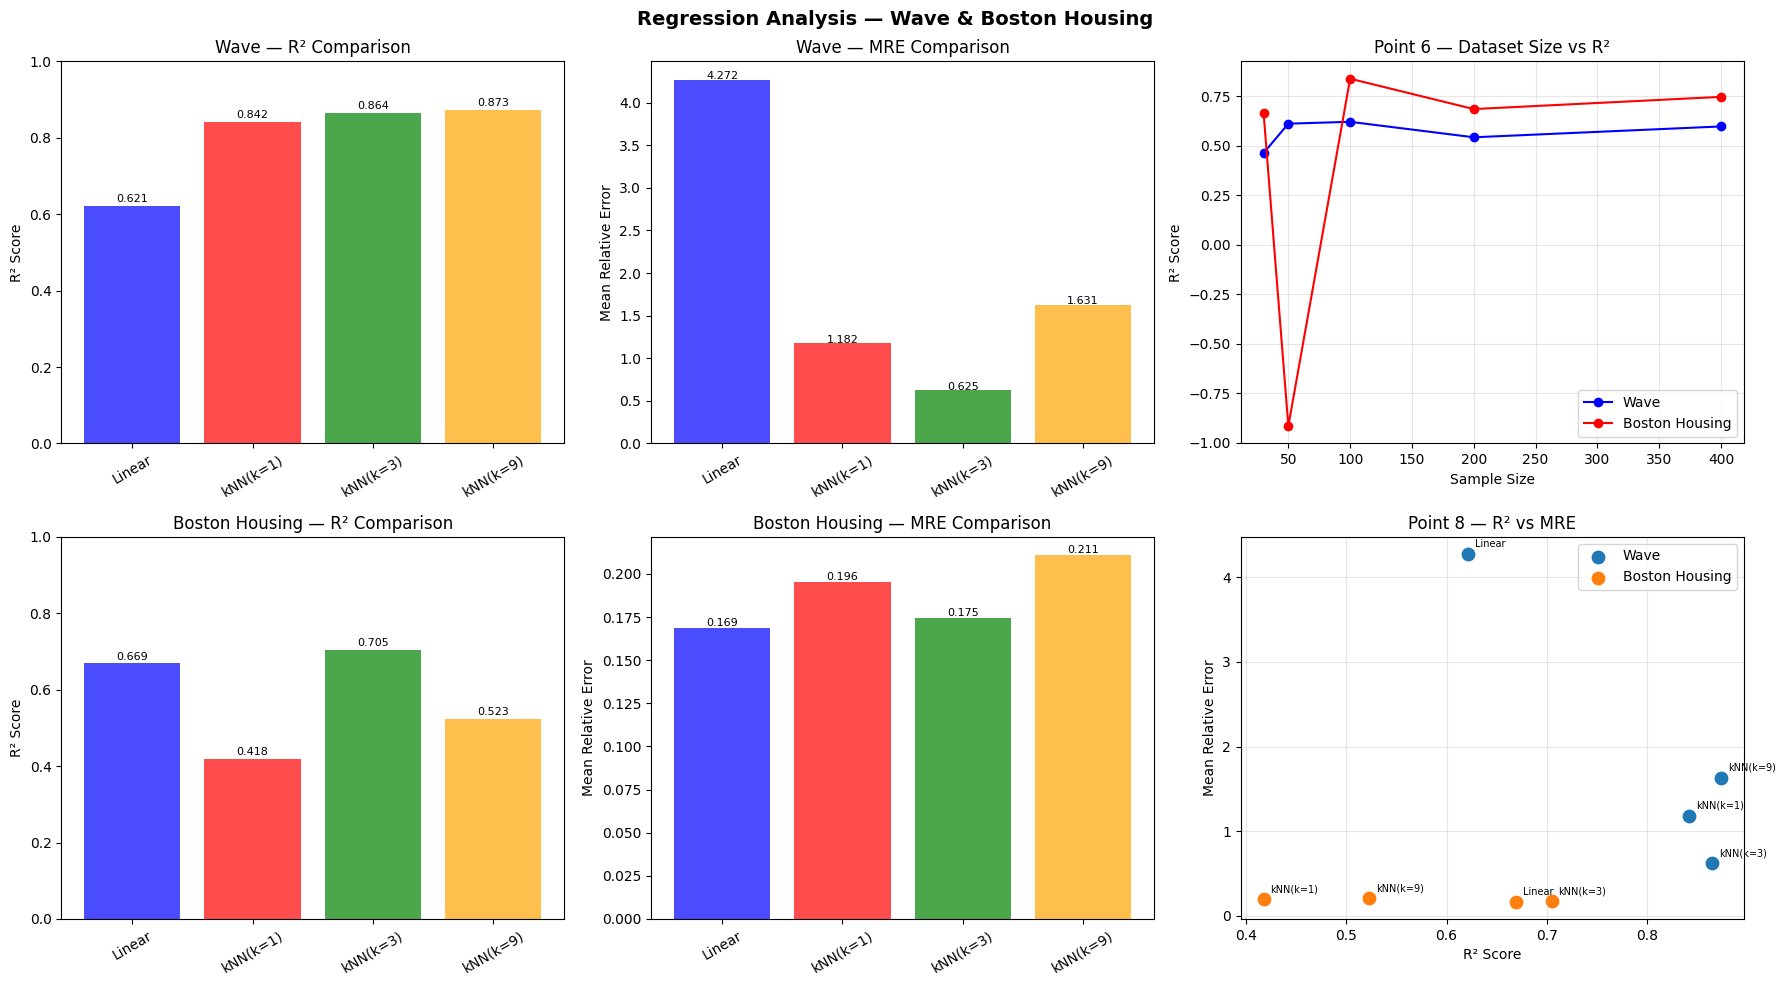

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ─── Boston Housing Dataset ───────────────────────────────────────────────────
# Boston dataset was removed from sklearn, so we load it manually
import pandas as pd

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
X_housing = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y_housing = raw_df.values[1::2, 2]

# ─── Wave Dataset Generator ───────────────────────────────────────────────────
def make_wave(n_samples=100):
    np.random.seed(42)
    X = np.random.uniform(-3, 3, (n_samples, 1))
    y = np.sin(X).ravel() + np.random.normal(0, 0.3, n_samples)
    return X, y

# ─── Mean Relative Error ──────────────────────────────────────────────────────
def mean_relative_error(actual, predicted):
    return np.mean(np.abs(predicted - actual) / np.abs(actual))

# ─── Load Datasets ────────────────────────────────────────────────────────────
X_wave, y_wave = make_wave(n_samples=100)

# Train-test split
X_wave_train, X_wave_test, y_wave_train, y_wave_test = train_test_split(
    X_wave, y_wave, test_size=0.2, random_state=42)

X_hous_train, X_hous_test, y_hous_train, y_hous_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42)

# ─── 2. Mean Relative Error Computation ──────────────────────────────────────
print("=" * 60)
print("POINT 2 — Mean Relative Error (Linear Regression)")
print("=" * 60)

for name, Xtr, Xte, ytr, yte in [
    ("Wave",           X_wave_train, X_wave_test, y_wave_train, y_wave_test),
    ("Boston Housing", X_hous_train, X_hous_test, y_hous_train, y_hous_test),
]:
    lr = LinearRegression().fit(Xtr, ytr)
    pred = lr.predict(Xte)
    mre = mean_relative_error(yte, pred)
    print(f"  {name:20s} → MRE = {mre:.4f}")

# ─── 3. Linear vs kNN Regression (R² and MRE) ────────────────────────────────
print("\n" + "=" * 60)
print("POINT 3 — Linear vs kNN Regression (R² & MRE)")
print("=" * 60)

k_values = [1, 3, 9]
datasets = {
    "Wave":           (X_wave_train, X_wave_test, y_wave_train, y_wave_test),
    "Boston Housing": (X_hous_train, X_hous_test, y_hous_train, y_hous_test),
}

results = {}

for dname, (Xtr, Xte, ytr, yte) in datasets.items():
    results[dname] = {}
    print(f"\n  Dataset: {dname}")
    print(f"  {'Model':<20} {'R²':>8} {'MRE':>10}")
    print(f"  {'-'*40}")

    # Linear Regression
    lr = LinearRegression().fit(Xtr, ytr)
    pred_lr = lr.predict(Xte)
    r2_lr   = r2_score(yte, pred_lr)
    mre_lr  = mean_relative_error(yte, pred_lr)
    results[dname]["Linear"] = (r2_lr, mre_lr)
    print(f"  {'Linear Regression':<20} {r2_lr:>8.4f} {mre_lr:>10.4f}")

    # kNN Regression
    for k in k_values:
        knn = KNeighborsRegressor(n_neighbors=k).fit(Xtr, ytr)
        pred_knn = knn.predict(Xte)
        r2_knn   = r2_score(yte, pred_knn)
        mre_knn  = mean_relative_error(yte, pred_knn)
        results[dname][f"kNN(k={k})"] = (r2_knn, mre_knn)
        print(f"  {'kNN (k='+str(k)+')':<20} {r2_knn:>8.4f} {mre_knn:>10.4f}")

# ─── 6. Impact of Dataset Variation on R² ────────────────────────────────────
print("\n" + "=" * 60)
print("POINT 6 — Impact of Dataset Variation on R²")
print("=" * 60)

sample_sizes = [30, 50, 100, 200, 400]
r2_wave_sizes, r2_hous_sizes = [], []

for n in sample_sizes:
    # Wave — vary sample size
    Xw, yw = make_wave(n_samples=n)
    Xwtr, Xwte, ywtr, ywte = train_test_split(Xw, yw, test_size=0.2, random_state=42)
    lr_w = LinearRegression().fit(Xwtr, ywtr)
    r2_wave_sizes.append(r2_score(ywte, lr_w.predict(Xwte)))

    # Boston Housing — subsample
    idx = np.random.RandomState(42).choice(len(X_housing), size=min(n, len(X_housing)), replace=False)
    Xh, yh = X_housing[idx], y_housing[idx]
    Xhtr, Xhte, yhtr, yhte = train_test_split(Xh, yh, test_size=0.2, random_state=42)
    lr_h = LinearRegression().fit(Xhtr, yhtr)
    r2_hous_sizes.append(r2_score(yhte, lr_h.predict(Xhte)))

print(f"\n  {'Sample Size':<14}", " ".join(f"{n:>8}" for n in sample_sizes))
print(f"  {'Wave R²':<14}", " ".join(f"{v:>8.4f}" for v in r2_wave_sizes))
print(f"  {'Boston R²':<14}", " ".join(f"{v:>8.4f}" for v in r2_hous_sizes))

# ─── 8. Impact of R² on MRE ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("POINT 8 — Impact of R² on Mean Relative Error")
print("=" * 60)

for dname, models in results.items():
    print(f"\n  Dataset: {dname}")
    print(f"  {'Model':<20} {'R²':>8} {'MRE':>10} {'Relationship'}")
    print(f"  {'-'*55}")
    sorted_models = sorted(models.items(), key=lambda x: -x[1][0])
    for mname, (r2, mre) in sorted_models:
        rel = "Higher R² → Lower MRE ✅" if r2 > 0.5 else "Low R² → Higher MRE ⚠️"
        print(f"  {mname:<20} {r2:>8.4f} {mre:>10.4f}  {rel}")

# ─── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Regression Analysis — Wave & Boston Housing", fontsize=14, fontweight='bold')

colors = {'Linear': 'blue', 'kNN(k=1)': 'red', 'kNN(k=3)': 'green', 'kNN(k=9)': 'orange'}

# Plot 1 & 2 — R² comparison bar charts
for idx, (dname, models) in enumerate(results.items()):
    ax = axes[idx][0]
    names = list(models.keys())
    r2s   = [v[0] for v in models.values()]
    bars  = ax.bar(names, r2s, color=[colors[n] for n in names], alpha=0.7)
    ax.set_title(f"{dname} — R² Comparison")
    ax.set_ylabel("R² Score")
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, r2s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha='center', fontsize=8)

# Plot 3 & 4 — MRE comparison bar charts
for idx, (dname, models) in enumerate(results.items()):
    ax = axes[idx][1]
    names = list(models.keys())
    mres  = [v[1] for v in models.values()]
    bars  = ax.bar(names, mres, color=[colors[n] for n in names], alpha=0.7)
    ax.set_title(f"{dname} — MRE Comparison")
    ax.set_ylabel("Mean Relative Error")
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, mres):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha='center', fontsize=8)

# Plot 5 — Dataset variation vs R²
ax = axes[0][2]
ax.plot(sample_sizes, r2_wave_sizes, 'b-o', label='Wave')
ax.plot(sample_sizes, r2_hous_sizes, 'r-o', label='Boston Housing')
ax.set_title("Point 6 — Dataset Size vs R²")
ax.set_xlabel("Sample Size")
ax.set_ylabel("R² Score")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6 — R² vs MRE scatter
ax = axes[1][2]
for dname, models in results.items():
    r2s  = [v[0] for v in models.values()]
    mres = [v[1] for v in models.values()]
    ax.scatter(r2s, mres, label=dname, s=80)
    for i, mname in enumerate(models.keys()):
        ax.annotate(mname, (r2s[i], mres[i]), fontsize=7,
                    xytext=(5, 5), textcoords='offset points')
ax.set_title("Point 8 — R² vs MRE")
ax.set_xlabel("R² Score")
ax.set_ylabel("Mean Relative Error")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()